# Домашнее задание №4: анализ данных LUNA16 для задачи детекции лёгочных узлов


## 1. Источник и состав данных

Датасет LUNA16. Датасет включает в себя КТ-сканы с размеченными патологическими изменениями и нормальные КТ-сканы без патологии.

Описание таблиц:
- `annotations.csv`: содержит координаты патологических узлов и их диаметр в миллиметрах.
- `candidates_V2.csv`: содержит координаты точек. В столбце `class`, `1` соответствует КТ-скану с патологическим узлом, а `0` — без патологии.
- `sampleSubmission.csv`: показывает, в каком формате модель должна возвращать координаты патологического узла и вероятность наличия узла.

Для анализа будет использоваться не весь КТ-скан целиком, а 3D-патч вокруг патологического узла.

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)

annotations = pd.read_csv("annotations.csv")

# В разных версиях файла кандидаты могут называться candidates.csv или candidates_V2.csv
if os.path.exists("candidates.csv"):
    candidates = pd.read_csv("candidates.csv")
elif os.path.exists("candidates_V2.csv"):
    candidates = pd.read_csv("candidates_V2.csv")
else:
    raise FileNotFoundError("Не найден файл candidates.csv или candidates_V2.csv")

sample_submission = pd.read_csv("sampleSubmission.csv")

print("annotations:", annotations.shape)
print("candidates:", candidates.shape)
print("sample_submission:", sample_submission.shape)

display(annotations.head())
display(candidates.head())
display(sample_submission.head())

annotations: (1186, 5)
candidates: (754975, 5)
sample_submission: (8, 5)


,seriesuid,coordX,coordY,coordZ,diameter_mm
0,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,-128.699421,-175.319272,-298.387506,5.651471
1,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,103.783651,-211.925149,-227.121250,4.224708
2,1.3.6.1.4.1.14519.5.2.1.6279.6001.100398138793...,69.639017,-140.944586,876.374496,5.786348
3,1.3.6.1.4.1.14519.5.2.1.6279.6001.100621383016...,-24.013824,192.102405,-391.081276,8.143262
4,1.3.6.1.4.1.14519.5.2.1.6279.6001.100621383016...,2.441547,172.464881,-405.493732,18.545150


,seriesuid,coordX,coordY,coordZ,class
0,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,68.420000,-74.480000,-288.700000,0
1,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,-95.209361,-91.809406,-377.426350,0
2,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,-24.766755,-120.379294,-273.361539,0
3,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,-63.080000,-65.740000,-344.240000,0
4,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,52.946688,-92.688873,-241.067872,0


,seriesuid,coordX,coordY,coordZ,probability
0,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,-128.6,-175.3,-298.3,1.0
1,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,103.7,-211.9,-227.1,0.8
2,1.3.6.1.4.1.14519.5.2.1.6279.6001.100398138793...,69.6,-140.9,876.3,0.2
3,1.3.6.1.4.1.14519.5.2.1.6279.6001.100621383016...,-24.0,192.1,-391.0,0.5
4,1.3.6.1.4.1.14519.5.2.1.6279.6001.100621383016...,2.4,172.4,-405.4,1.0


In [3]:
print("annotations columns:")
display(pd.DataFrame({"column": annotations.columns, "dtype": annotations.dtypes.astype(str).values}))

print("candidates columns:")
display(pd.DataFrame({"column": candidates.columns, "dtype": candidates.dtypes.astype(str).values}))

print("sample_submission columns:")
display(pd.DataFrame({"column": sample_submission.columns, "dtype": sample_submission.dtypes.astype(str).values}))

annotations columns:


,column,dtype
0,seriesuid,object
1,coordX,float64
2,coordY,float64
3,coordZ,float64
4,diameter_mm,float64


candidates columns:


,column,dtype
0,seriesuid,object
1,coordX,float64
2,coordY,float64
3,coordZ,float64
4,class,int64


sample_submission columns:


,column,dtype
0,seriesuid,object
1,coordX,float64
2,coordY,float64
3,coordZ,float64
4,probability,float64


## 2. Базовый EDA 

Проверяем размер датасета, пропуски, дубликаты, баланс классов, размеры узлов и распределение количества объектов по КТ-сканам.

In [5]:
summary = pd.DataFrame({
    "dataset": ["annotations", "candidates", "sample_submission"],
    "rows": [len(annotations), len(candidates), len(sample_submission)],
    "columns": [annotations.shape[1], candidates.shape[1], sample_submission.shape[1]],
    "unique_seriesuid": [annotations["seriesuid"].nunique(), candidates["seriesuid"].nunique(), sample_submission["seriesuid"].nunique()],
    "duplicates": [annotations.duplicated().sum(), candidates.duplicated().sum(), sample_submission.duplicated().sum()]
})

summary

,dataset,rows,columns,unique_seriesuid,duplicates
0,annotations,1186,5,601,0
1,candidates,754975,5,888,0
2,sample_submission,8,5,4,0


In [6]:
print("Пропуски в annotations")
display(annotations.isna().sum())

print("Пропуски в candidates")
display(candidates.isna().sum())

print("Пропуски в sample_submission")
display(sample_submission.isna().sum())

Пропуски в annotations


seriesuid      0
coordX         0
coordY         0
coordZ         0
diameter_mm    0
dtype: int64

Пропуски в candidates


seriesuid    0
coordX       0
coordY       0
coordZ       0
class        0
dtype: int64

Пропуски в sample_submission


seriesuid      0
coordX         0
coordY         0
coordZ         0
probability    0
dtype: int64

In [7]:
# Распределение классов в candidates
class_counts = candidates["class"].value_counts().sort_index()
class_share = candidates["class"].value_counts(normalize=True).sort_index() * 100

class_balance = pd.DataFrame({
    "count": class_counts,
    "share_percent": class_share.round(3)
})

display(class_balance)

,count,share_percent
class,,
0,753418,99.794
1,1557,0.206


**Вывод для моделирования:** данные по кандидатам несбалансированы: отрицательных кандидатов существенно больше, чем положительных. Поэтому accuracy не должна быть основной метрикой. Для медицинской задачи важнее контролировать F1/F2 и число ложноположительных срабатываний.

Диаметр истинных узлов, мм


count    1186.000000
mean        8.306527
std         4.762033
min         3.253443
25%         5.107177
50%         6.433600
75%         9.696301
max        32.270030
Name: diameter_mm, dtype: float64

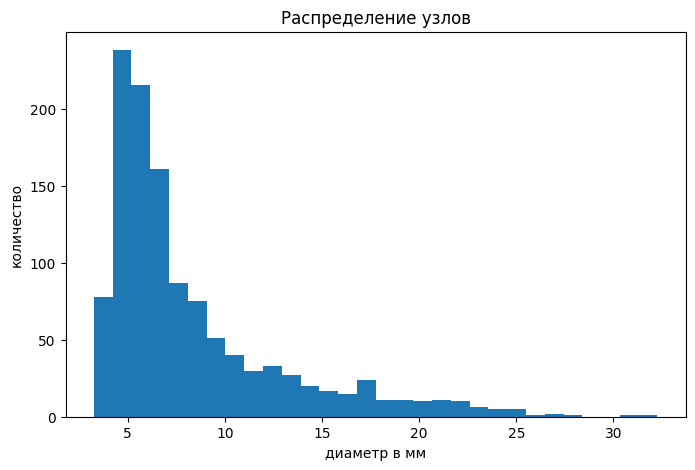

In [10]:
# Описательная статистика по диаметрам истинных узлов
print("Диаметр истинных узлов, мм")
display(annotations["diameter_mm"].describe())

plt.figure(figsize=(8, 5))
plt.hist(annotations["diameter_mm"], bins=30)
plt.xlabel("диаметр в мм")
plt.ylabel("количество")
plt.title("Распределение узлов")
plt.show()

In [11]:
nodules_per_scan = annotations.groupby("seriesuid").size()
candidates_per_scan = candidates.groupby("seriesuid").size()
positive_candidates_per_scan = candidates[candidates["class"] == 1].groupby("seriesuid").size()

scan_stats = pd.DataFrame({
    "nodules_per_scan": nodules_per_scan.describe(),
    "candidates_per_scan": candidates_per_scan.describe(),
    "positive_candidates_per_scan": positive_candidates_per_scan.describe()
})

display(scan_stats)

,nodules_per_scan,candidates_per_scan,positive_candidates_per_scan
count,601.000000,888.000000,600.000000
mean,1.973378,850.197072,2.595000
std,1.483000,293.236676,2.301406
min,1.000000,66.000000,1.000000
25%,1.000000,654.500000,1.000000
50%,1.000000,837.500000,2.000000
75%,2.000000,1029.750000,3.000000
max,12.000000,2066.000000,17.000000


**Вывод:** В датасете присутствует дисбаланс между положительными и отрицательными точками координат. Количество положительных находок значительно меньше общего числа областей, что необходимо учитывать при обучении модели (стратификация, подбор метрик, балансировка классов).

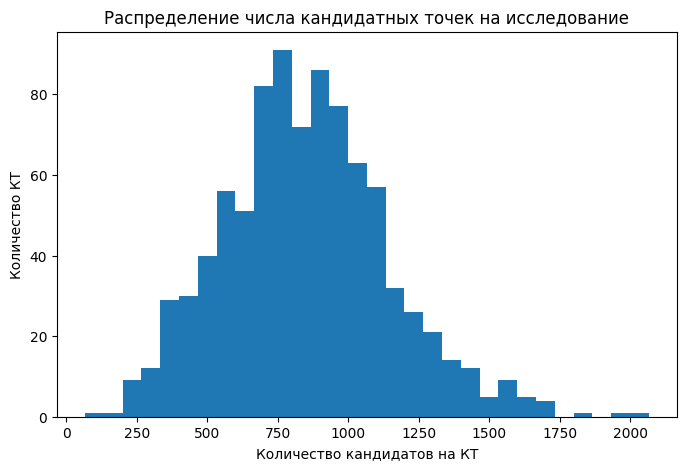

In [12]:
plt.figure(figsize=(8, 5))
plt.hist(candidates_per_scan, bins=30)
plt.xlabel("Количество кандидатов на КТ")
plt.ylabel("Количество КТ")
plt.title("Распределение числа кандидатных точек на исследование")
plt.show()

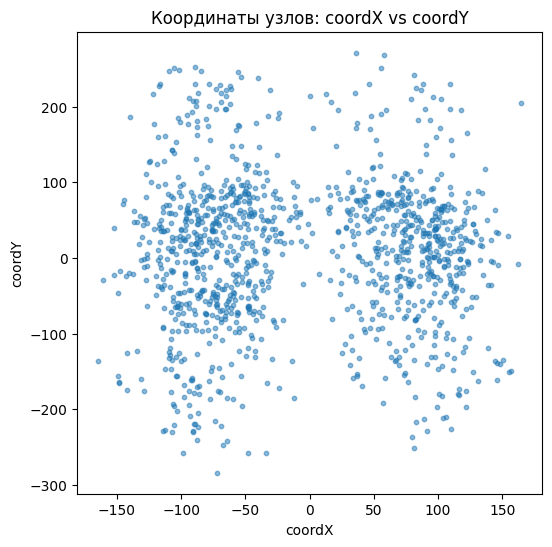

In [14]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(annotations["coordX"], annotations["coordY"], alpha=0.5, s=10)
ax.set_xlabel("coordX")
ax.set_ylabel("coordY")
ax.set_title("Координаты узлов: coordX vs coordY")
plt.show()

## 3. Оценка качества разметки и предложения по улучшению

In [15]:
quality_checks = pd.DataFrame({
    "check": [
        "Пропуски в annotations",
        "Дубликаты в annotations",
        "diameter_mm <= 0",
        "Пропуски в candidates",
        "Дубликаты в candidates",
        "Некорректные значения class"
    ],
    "result": [
        int(annotations.isna().sum().sum()),
        int(annotations.duplicated().sum()),
        int((annotations["diameter_mm"] <= 0).sum()),
        int(candidates.isna().sum().sum()),
        int(candidates.duplicated().sum()),
        int((~candidates["class"].isin([0, 1])).sum())
    ]
})

display(quality_checks)

,check,result
0,Пропуски в annotations,0
1,Дубликаты в annotations,0
2,diameter_mm <= 0,0
3,Пропуски в candidates,0
4,Дубликаты в candidates,0
5,Некорректные значения class,0


In [19]:
#Вывод: проведённая проверка показала отсутствие очевидных проблем качества данных: пропусков, дублирующихся записей и некорректных значений в ключевых полях.

## 4. Алгоритм формирования выборки для решения задачи

Задача формулируется как бинарная классификация 3D-патчей:
- `1`: патч вокруг положительного истинного узла;
- `0`: патч вокруг отрицательного кандидата.

Общий алгоритм:
1. Загрузить таблицу кандидатов и исходные КТ-файлы `.mhd`.
2. Для каждой кандидатной точки взять координаты `coordX`, `coordY`, `coordZ`.
3. Перевести координаты из миллиметров в индексы массива КТ через `origin` и `spacing`.
4. Вырезать 3D-патч фиксированного размера, например `32 × 32 × 32` voxel.
5. Нормализовать интенсивности КТ, например ограничить HU-диапазон и привести значения к сопоставимому масштабу.
6. Сформировать `X` из патчей и `y` из столбца `class`.
7. Разделить данные на train/validation/test по `seriesuid`, а не по отдельным патчам.
8. Для дисбаланса классов использовать undersampling отрицательных кандидатов, class weights или balanced sampler.

In [21]:
def world_to_voxel(world_coord, origin, spacing):
    """Перевод координат из системы координат КТ в индексы массива numpy."""
    world_coord = np.array(world_coord)
    origin = np.array(origin)
    spacing = np.array(spacing)

    voxel_xyz = np.round((world_coord - origin) / spacing).astype(int)
    voxel_zyx = voxel_xyz[::-1]
    return voxel_zyx


def get_patch(image, voxel, size=32):
    """Вырезает 3D-патч вокруг центра.
    Если патч выходит за границы КТ, недостающие области заполняются нулями.
    """
    z, y, x = voxel
    half = size // 2

    patch = np.zeros((size, size, size), dtype=image.dtype)

    z_min, z_max = z - half, z + half
    y_min, y_max = y - half, y + half
    x_min, x_max = x - half, x + half

    img_z_min = max(z_min, 0)
    img_z_max = min(z_max, image.shape[0])
    img_y_min = max(y_min, 0)
    img_y_max = min(y_max, image.shape[1])
    img_x_min = max(x_min, 0)
    img_x_max = min(x_max, image.shape[2])

    if img_z_min >= img_z_max or img_y_min >= img_y_max or img_x_min >= img_x_max:
        return patch

    patch_z_min = img_z_min - z_min
    patch_y_min = img_y_min - y_min
    patch_x_min = img_x_min - x_min

    patch_z_max = patch_z_min + (img_z_max - img_z_min)
    patch_y_max = patch_y_min + (img_y_max - img_y_min)
    patch_x_max = patch_x_min + (img_x_max - img_x_min)

    patch[patch_z_min:patch_z_max, patch_y_min:patch_y_max, patch_x_min:patch_x_max] = image[
        img_z_min:img_z_max, img_y_min:img_y_max, img_x_min:img_x_max
    ]

    return patch

## 5. Стратегия валидации

- делить данные по `seriesuid`;
- использовать `GroupShuffleSplit` для train/validation/test или `GroupKFold` для кросс-валидации;
- отдельно контролировать долю положительных кандидатов в каждой части выборки.

In [22]:
from sklearn.model_selection import GroupShuffleSplit

X_meta = candidates[["seriesuid", "coordX", "coordY", "coordZ"]].copy()
y_meta = candidates["class"].copy()
groups = candidates["seriesuid"].copy()

splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, valid_idx = next(splitter.split(X_meta, y_meta, groups=groups))

train_meta = candidates.iloc[train_idx]
valid_meta = candidates.iloc[valid_idx]

print("train shape:", train_meta.shape)
print("valid shape:", valid_meta.shape)
print("Пересечение seriesuid:", len(set(train_meta["seriesuid"]) & set(valid_meta["seriesuid"])))

validation_summary = pd.DataFrame({
    "part": ["train", "valid"],
    "rows": [len(train_meta), len(valid_meta)],
    "unique_seriesuid": [train_meta["seriesuid"].nunique(), valid_meta["seriesuid"].nunique()],
    "positive_share_percent": [train_meta["class"].mean() * 100, valid_meta["class"].mean() * 100]
})

display(validation_summary)

train shape: (605840, 5)
valid shape: (149135, 5)
Пересечение seriesuid: 0


,part,rows,unique_seriesuid,positive_share_percent
0,train,605840,710,0.205995
1,valid,149135,178,0.207195


## 6. Итоговые выводы для дальнейшего моделирования

1. Данные подходят для постановки задачи бинарной классификации 3D-патчей: положительный класс — кандидат с узлом, отрицательный класс — кандидат без узла.
2. В выборке выраженный дисбаланс классов, поэтому нельзя ориентироваться только на accuracy.
3. Для медицинского MVP приоритетны recall, F1, F2 и контроль ложноположительных срабатываний (FPR).
4. Разделение train/validation/test выполняется по `seriesuid`.
5. Перед обучением модели нужно перевести координаты из физической системы координат КТ в voxel-индексы, вырезать одинаковые 3D-патчи и нормализовать интенсивности.
6. Качество разметки по доступным таблицам хорошее, отсутствуют пропуски, дубликаты и т.п.